In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


In [3]:
BASE_DIR = Path("../")

DATA = BASE_DIR / "data" / "processed"

nav = pd.read_csv(DATA / "nav_history_clean.csv")

fund = pd.read_csv(DATA / "fund_master_clean.csv")


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav.head()


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


#### Daily Return Calculation using:

Daily Return = (Today's NAV / Previous Day's NAV) − 1

This helps measure the day-to-day change in fund value.

In [5]:
nav["daily_return"] = (

    nav.groupby("amfi_code")["nav"]

    .pct_change()

)

nav.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
# remove rows with missing daily returns
returns = nav.dropna(
    subset=["daily_return"]
)

returns.head()


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


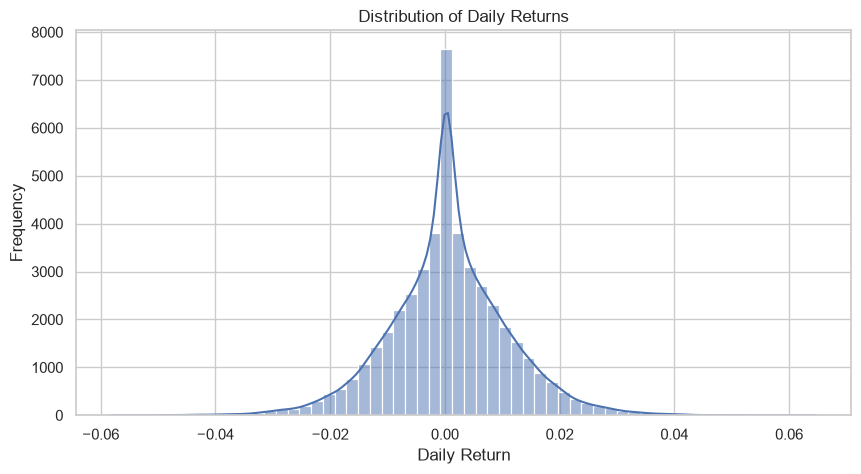

In [7]:
# Distribution of Daily Returns
plt.figure(figsize=(10,5))

sns.histplot(

    returns["daily_return"],

    bins=60,

    kde=True

)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


In [8]:
returns.to_csv(

    DATA/"daily_returns.csv",

    index=False

)

print("Daily returns saved successfully.")


Daily returns saved successfully.


#### CAGR Analysis
it measures the average annual growth of a mutual fund over a specific investment period.

In [9]:
# Merge Scheme Name
returns = returns.merge(

    fund[["amfi_code","scheme_name"]],
    on="amfi_code",

    how="left"

)


In [10]:
# cagr function
def calculate_cagr(start_nav,end_nav,years):

    return (

        (end_nav/start_nav)

        **(1/years)

        -1

    )


In [11]:
# cagr calculation

cagr_list=[]

for code,group in nav.groupby("amfi_code"):

    group=group.sort_values("date")

    end_nav=group.iloc[-1]["nav"]

    scheme=group.iloc[-1]["amfi_code"]

    name=fund.loc[
        fund["amfi_code"]==scheme,
        "scheme_name"
    ].values[0]

    row={

        "amfi_code":scheme,

        "scheme_name":name

    }

    for yrs in [1,3,5]:

        approx=252*yrs

        if len(group)>=approx:

            start_nav=group.iloc[-approx]["nav"]

            row[f"CAGR_{yrs}Y"]=calculate_cagr(

                start_nav,

                end_nav,

                yrs

            )*100

        else:

            row[f"CAGR_{yrs}Y"]=np.nan

    cagr_list.append(row)

cagr_df=pd.DataFrame(cagr_list)

cagr_df.head()


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-3.305509,-0.031628,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2.501760,4.614329,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,45.093927,32.528591,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.242050,-2.696475,NaN


In [12]:
# comparision table

cagr_df.sort_values(

    "CAGR_3Y",

    ascending=False

).head(10)


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,30.918202,36.066017,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,45.093927,32.528591,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.580715,31.278573,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,30.353412,30.206535,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,11.500730,28.369809,NaN
21,119598,SBI Small Cap Fund - Regular Plan - Growth,84.532246,27.814418,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,48.883881,27.727428,NaN
8,102887,UTI Flexi Cap Fund - Regular - Growth,12.727860,25.663042,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,28.481073,25.661883,NaN


In [13]:
cagr_df.to_csv(

    DATA/"cagr_comparison.csv",

    index=False

)


#### 
Funds with higher 3-year CAGR have shown stronger long-term growth compared to other schemes.

#### Sharpe Ratio
it measures the return earned for each unit of risk taken.
Risk-Free Rate (Rf) = 6.5%

In [14]:
# Risk-Free Rate
RF=0.065


In [15]:
# Calculate Sharpe Ratio
sharpe=[]

for code,group in returns.groupby("amfi_code"):

    mean=group["daily_return"].mean()*252

    std=group["daily_return"].std()*np.sqrt(252)

    value=(mean-RF)/std

    name=fund.loc[
        fund["amfi_code"]==code,
        "scheme_name"
    ].values[0]

    sharpe.append(

        [

            code,

            name,

            value

        ]

    )

sharpe_df=pd.DataFrame(

    sharpe,

    columns=[

        "amfi_code",

        "scheme_name",

        "Sharpe Ratio"

    ]

)


In [16]:
# done ranking by Sharpe Ratio
sharpe_df["Rank"]=sharpe_df[
    "Sharpe Ratio"
].rank(

    ascending=False

)

sharpe_df=sharpe_df.sort_values(

    "Rank"

)

sharpe_df.head(10)


,amfi_code,scheme_name,Sharpe Ratio,Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5.0
38,149323,DSP Midcap Fund - Regular - Growth,1.132122,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,8.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10.0


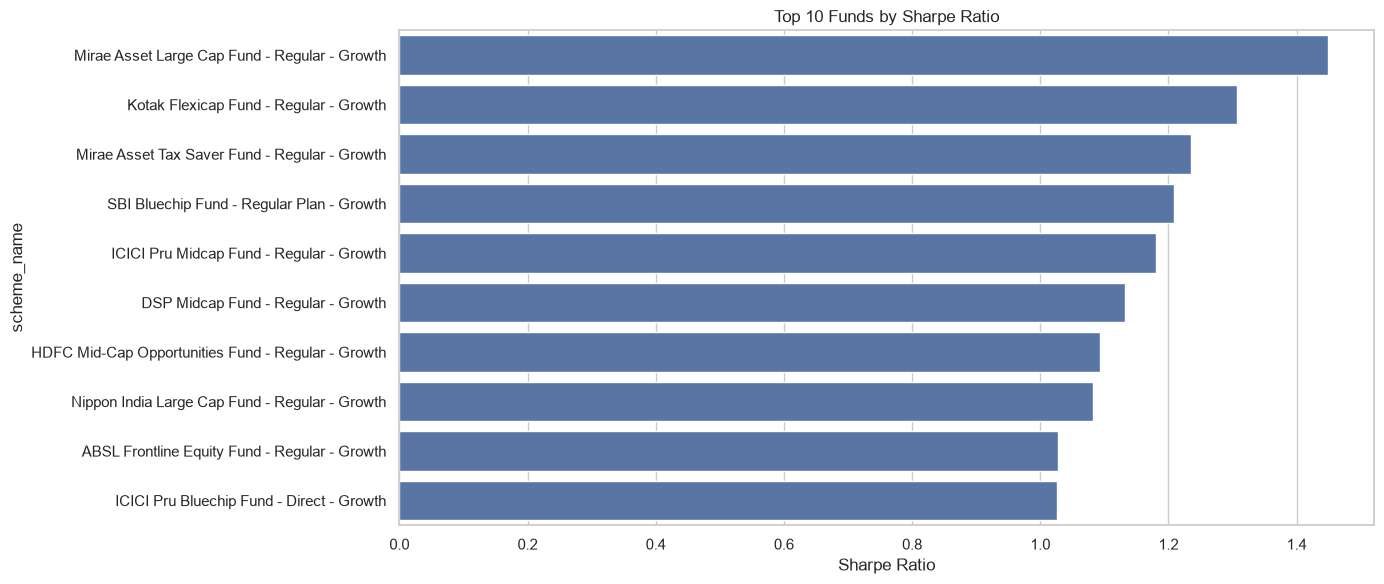

In [17]:
# bar chart
plt.figure(figsize=(14,6))

top10=sharpe_df.head(10)

sns.barplot(

    data=top10,

    x="Sharpe Ratio",

    y="scheme_name"

)

plt.title(

    "Top 10 Funds by Sharpe Ratio"

)

plt.tight_layout()

plt.savefig(

    "../reports/charts/sharpe_ratio.png",

    dpi=300

)

plt.show()


In [18]:
sharpe_df.to_csv(

    DATA/"sharpe_ratio.csv",

    index=False

)

print("Sharpe Ratio completed.")


Sharpe Ratio completed.


####
Funds with a higher Sharpe Ratio delivered better risk-adjusted returns, making them more efficient investments during the analysis period.


#### Sortino Ratio
It measures the risk-adjusted return of a fund by considering only downside risk. Unlike the Sharpe Ratio, it ignores positive return volatility and focuses only on negative return days.

In [19]:
sortino_result = []

for code, group in returns.groupby("amfi_code"):

    mean_return = group["daily_return"].mean() * 252

    downside = group[group["daily_return"] < 0]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (mean_return - RF) / downside_std

    scheme = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    sortino_result.append([
        code,
        scheme,
        sortino
    ])

sortino_df = pd.DataFrame(
    sortino_result,
    columns=[
        "amfi_code",
        "scheme_name",
        "Sortino Ratio"
    ]
)

sortino_df["Rank"] = sortino_df["Sortino Ratio"].rank(
    ascending=False
)

sortino_df.sort_values(
    "Rank",
    inplace=True
)

sortino_df.head(10)


,amfi_code,scheme_name,Sortino Ratio,Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,2.364320,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353,5.0
38,149323,DSP Midcap Fund - Regular - Growth,1.875101,6.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133,7.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134,8.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294,9.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563,10.0


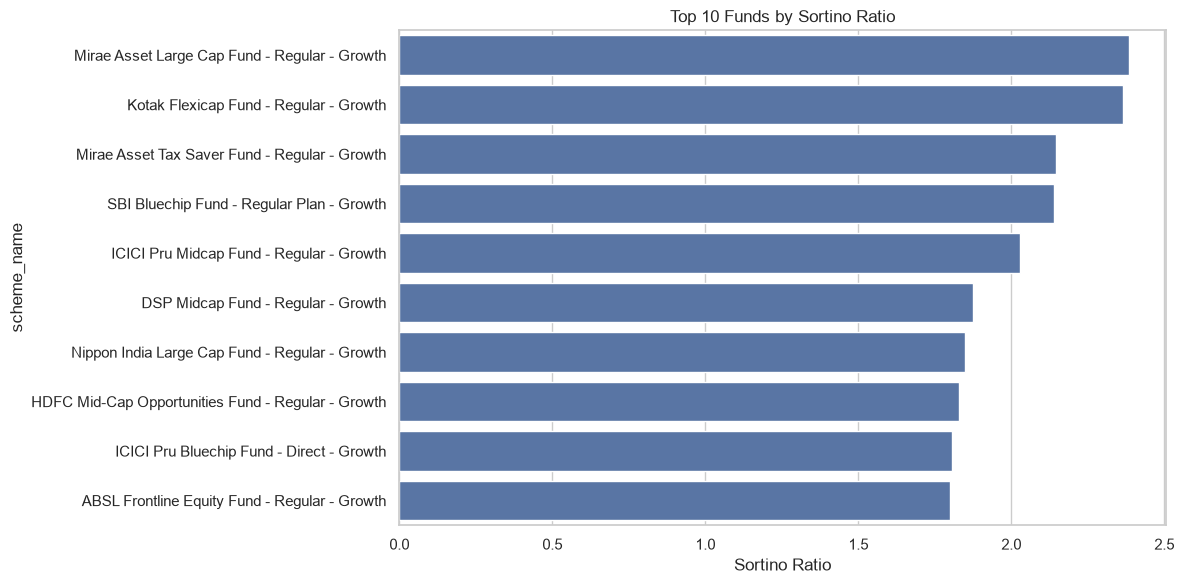

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="Sortino Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio.png",
    dpi=300
)

plt.show()


In [21]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)


####
Funds with a higher Sortino Ratio generated better returns while taking lower downside risk.

#### Alpha and Beta Analysis
Alpha measures the excess return generated by a fund after considering market performance.
Beta measures how sensitive a fund is to market movements. 
Both metrics are calculated using linear regression against the Nifty 100 benchmark.

In [22]:
from scipy.stats import linregress


In [38]:
benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark[
    "close_value"
].pct_change()

benchmark.head()


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [39]:
alpha_beta = []

for code, group in returns.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    scheme = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    alpha_beta.append([
        code,
        scheme,
        alpha,
        slope
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.head()


,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [40]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)


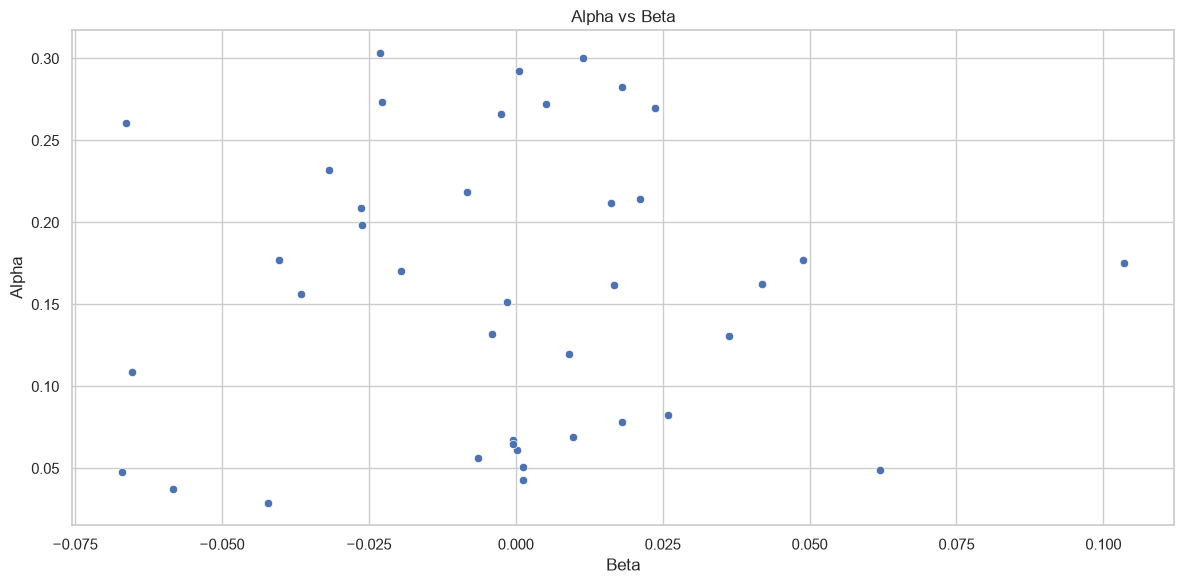

In [41]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=alpha_beta_df,
    x="Beta",
    y="Alpha"
)

plt.title("Alpha vs Beta")

plt.tight_layout()

plt.savefig(
    "../reports/charts/alpha_beta.png",
    dpi=300
)

plt.show()


####
Funds with positive alpha outperformed the benchmark, while beta values close to 1 indicate market-like volatility.


#### Maximum Drawdown

It will measures the largest percentage decline in a fund's NAV from its previous highest value. It helps identify the biggest loss experienced before recovery.

In [27]:
drawdown_result = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] /
        group["running_max"]
    ) - 1

    worst = group.loc[
        group["drawdown"].idxmin()
    ]

    peak = group.loc[
        group["nav"][:worst.name].idxmax()
    ]

    scheme = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    drawdown_result.append([

        code,

        scheme,

        peak["date"],

        worst["date"],

        worst["drawdown"]

    ])

drawdown_df = pd.DataFrame(

    drawdown_result,

    columns=[

        "amfi_code",

        "scheme_name",

        "Peak Date",

        "Worst Date",

        "Maximum Drawdown"

    ]

)

drawdown_df.head()


,amfi_code,scheme_name,Peak Date,Worst Date,Maximum Drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2025-11-28,2023-07-28,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2026-04-10,2022-05-12,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,2026-04-29,2023-07-05,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-0.354469


In [28]:
drawdown_df = drawdown_df.sort_values(
    "Maximum Drawdown"
)

drawdown_df.head(10)


,amfi_code,scheme_name,Peak Date,Worst Date,Maximum Drawdown
22,119599,SBI Small Cap Fund - Direct Plan - Growth,2023-01-17,2025-10-28,-0.525742
17,119095,Axis Small Cap Fund - Regular - Growth,2025-05-22,2026-05-11,-0.516778
4,101207,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-0.354469
39,149324,DSP Small Cap Fund - Regular - Growth,2026-04-24,2025-01-03,-0.311719
21,119598,SBI Small Cap Fund - Regular Plan - Growth,2026-05-22,2025-05-14,-0.287060
7,102886,UTI Mid Cap Fund - Regular - Growth,2025-01-07,2026-04-27,-0.280011
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-0.247344
29,120842,Kotak Emerging Equity Fund - Regular - Growth,2025-10-22,2024-10-17,-0.240035
11,118634,Nippon India Small Cap Fund - Regular - Growth,2026-05-08,2026-02-20,-0.233449
15,119093,Axis Bluechip Fund - Direct - Growth,2025-12-02,2023-05-22,-0.217514


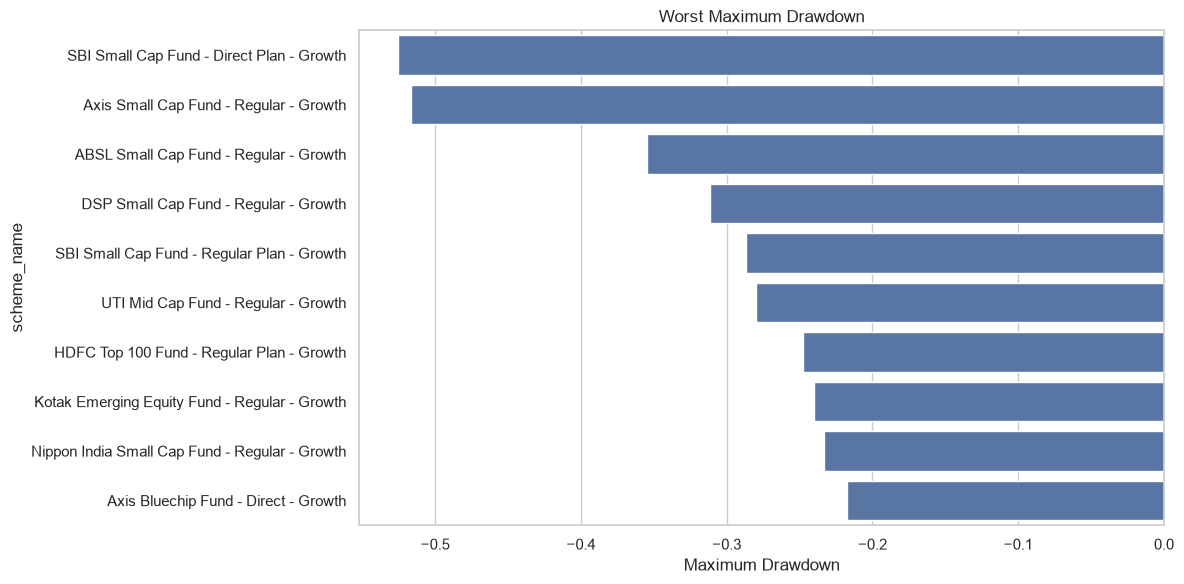

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=drawdown_df.head(10),
    x="Maximum Drawdown",
    y="scheme_name"
)

plt.title("Worst Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300
)

plt.show()


In [30]:
drawdown_df.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)


####
Funds with smaller maximum drawdowns were more stable during market corrections, while larger drawdowns indicate higher downside risk.


#### Fund Scorecard (0–100)
A composite score is calculated for each mutual fund using multiple performance metrics.
Weightage:
30% - 3-Year CAGR

25% - Sharpe Ratio

20% - Alpha

15% - Expense Ratio (Lower is Better)

10% - Maximum Drawdown (Lower is Better)

Higher scores indicate better overall fund performance.

In [42]:
# Expense Ratio
expense = fund[
    ["amfi_code", "expense_ratio_pct"]
].copy()


In [43]:
# Merge all performance metrics
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code","Sharpe Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code","Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code","Maximum Drawdown"]
    ],
    on="amfi_code"
)

scorecard.head()


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,expense_ratio_pct,Maximum Drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-3.305509,-0.031628,NaN,-0.201517,0.037476,1.55,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2.501760,4.614329,NaN,-0.567095,0.042818,0.56,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,NaN,1.093699,0.271954,1.38,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,45.093927,32.528591,NaN,1.027213,0.213998,1.60,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,-24.242050,-2.696475,NaN,0.162661,0.108971,1.53,-0.354469


In [44]:
# Ranking
scorecard["Return Rank"] = scorecard[
    "CAGR_3Y"
].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard[
    "Sharpe Ratio"
].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard[
    "Alpha"
].rank(ascending=False)

scorecard["Expense Rank"] = scorecard[
    "expense_ratio_pct"
].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard[
    "Maximum Drawdown"
].rank(ascending=True)


In [45]:
# Convert ranks into 0-100 scores
n = len(scorecard)

scorecard["Return Score"] = (
    (n-scorecard["Return Rank"])/(n-1)
)*100

scorecard["Sharpe Score"] = (
    (n-scorecard["Sharpe Rank"])/(n-1)
)*100

scorecard["Alpha Score"] = (
    (n-scorecard["Alpha Rank"])/(n-1)
)*100

scorecard["Expense Score"] = (
    (n-scorecard["Expense Rank"])/(n-1)
)*100

scorecard["Drawdown Score"] = (
    (n-scorecard["Drawdown Rank"])/(n-1)
)*100


In [46]:
# Final Score
scorecard["Fund Score"] = (

      0.30*scorecard["Return Score"]

    + 0.25*scorecard["Sharpe Score"]

    + 0.20*scorecard["Alpha Score"]

    + 0.15*scorecard["Expense Score"]

    + 0.10*scorecard["Drawdown Score"]

)

scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head(10)


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,expense_ratio_pct,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Return Score,Sharpe Score,Alpha Score,Expense Score,Drawdown Score,Fund Score
25,120505,ICICI Pru Midcap Fund - Regular - Growth,30.353412,30.206535,NaN,1.180101,0.292636,1.36,-0.181885,5.0,5.0,3.0,15.0,16.0,89.743590,89.743590,94.871795,64.102564,61.538462,84.102564
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,NaN,1.093699,0.271954,1.38,-0.162172,2.0,7.0,6.0,17.0,21.0,97.435897,84.615385,87.179487,58.974359,48.717949,81.538462
16,119094,Axis Midcap Fund - Regular - Growth,30.918202,36.066017,NaN,0.998231,0.260767,1.38,-0.209609,1.0,11.0,9.0,17.0,13.0,100.000000,74.358974,79.487179,58.974359,69.230769,80.256410
21,119598,SBI Small Cap Fund - Regular Plan - Growth,84.532246,27.814418,NaN,0.945308,0.303370,1.43,-0.287060,7.0,14.0,1.0,21.0,5.0,84.615385,66.666667,100.000000,48.717949,89.743590,78.333333
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.580715,31.278573,NaN,1.448291,0.269838,1.46,-0.112657,4.0,1.0,7.0,23.0,33.0,92.307692,100.000000,84.615385,43.589744,17.948718,77.948718
30,120843,Kotak Flexicap Fund - Regular - Growth,28.481073,25.661883,NaN,1.306744,0.273305,1.45,-0.129740,10.0,2.0,5.0,22.0,28.0,76.923077,97.435897,89.743590,46.153846,30.769231,75.384615
39,149324,DSP Small Cap Fund - Regular - Growth,62.081812,25.029675,NaN,0.949796,0.300579,1.52,-0.311719,11.0,13.0,2.0,26.5,4.0,74.358974,69.230769,97.435897,34.615385,92.307692,73.525641
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,11.500730,28.369809,NaN,1.026524,0.211948,0.80,-0.125883,6.0,10.0,13.0,12.0,29.0,87.179487,76.923077,69.230769,71.794872,28.205128,72.820513
19,119551,SBI Bluechip Fund - Regular Plan - Growth,48.883881,27.727428,NaN,1.208267,0.232010,1.54,-0.150124,8.0,4.0,10.0,30.5,24.0,82.051282,92.307692,76.923077,24.358974,41.025641,70.833333
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,44.465744,23.317123,NaN,1.234930,0.282704,1.60,-0.163967,13.0,3.0,4.0,36.5,20.0,69.230769,94.871795,92.307692,8.974359,51.282051,69.423077


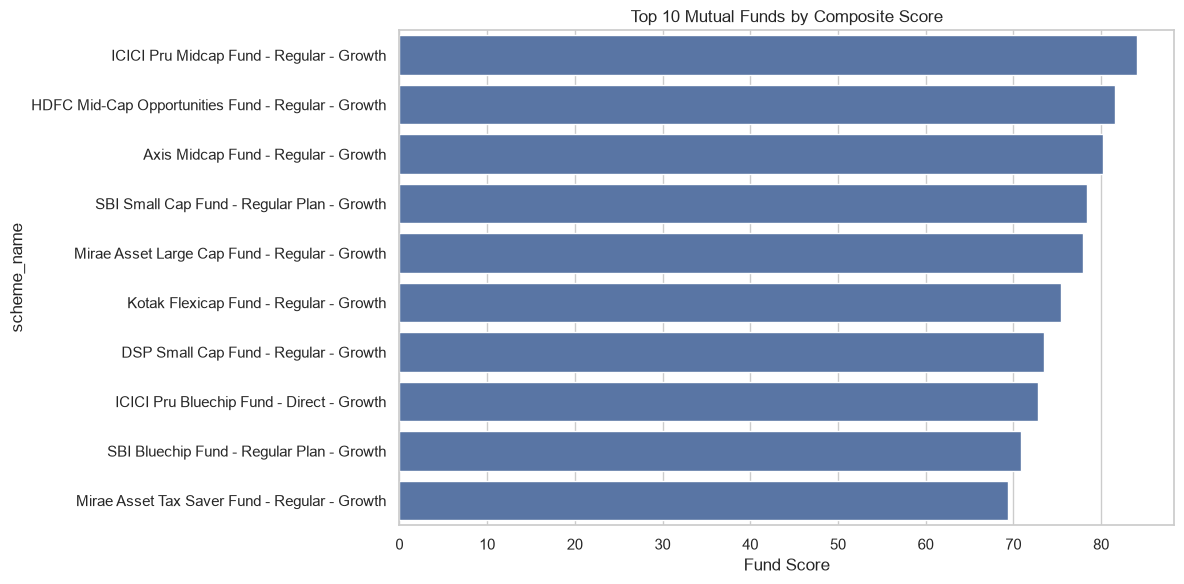

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(

    data=scorecard.head(10),

    x="Fund Score",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.tight_layout()

plt.savefig(

    "../reports/charts/fund_scorecard.png",

    dpi=300

)

plt.show()


In [48]:
scorecard.to_csv(

    "../data/processed/fund_scorecard.csv",

    index=False

)

print("Fund Scorecard Saved Successfully")


Fund Scorecard Saved Successfully


####
Funds with high returns, better Sharpe Ratio, positive Alpha, lower expense ratio, and lower drawdown achieved the highest overall score.

#### Benchmark Comparison
This analysis compares the top five mutual funds with the Nifty 50 and Nifty 100 indices over the last three years. Tracking Error is also calculated to measure how closely each fund follows the benchmark.

In [49]:
benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
]


In [50]:
# Top-5-funds
top5 = scorecard.head(5)["amfi_code"]

top_nav = nav[
    nav["amfi_code"].isin(top5)
]

top_nav = top_nav.merge(

    fund[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)


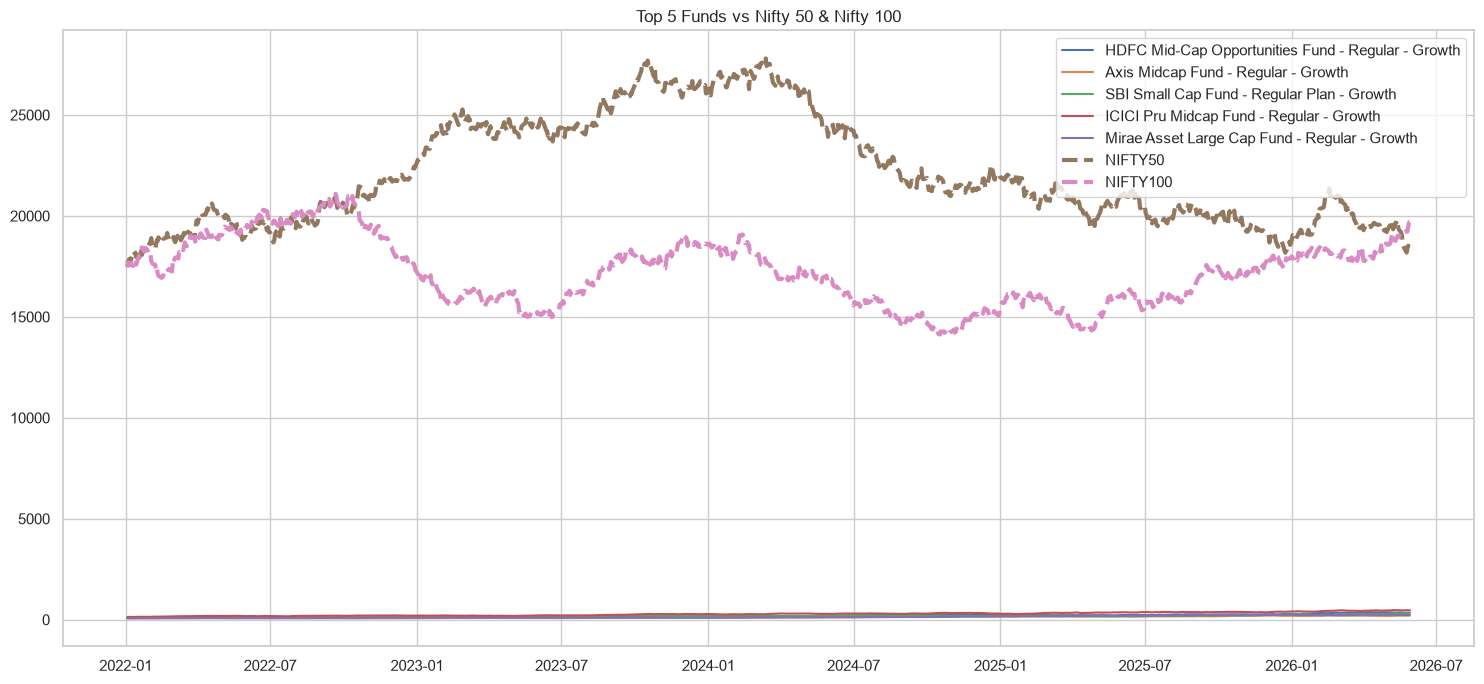

In [51]:

plt.figure(figsize=(15,7))

# Plot Top-5-Funds
for scheme in top_nav["scheme_name"].unique():

    temp = top_nav[
        top_nav["scheme_name"]==scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

# Plot Benchmarks
for index in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"]==index
    ]

    plt.plot(

        temp["date"],

        temp["close_value"],

        linewidth=3,

        linestyle="--",

        label=index

    )

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100")
plt.legend()
plt.tight_layout()
plt.savefig(

    "../reports/charts/benchmark_comparison.png",

    dpi=300

)

plt.show()


In [52]:
# Calculate Benchmark-returns

benchmark["benchmark_return"] = (

    benchmark.groupby("index_name")["close_value"]

    .pct_change()

)


In [53]:
tracking=[]

nifty100 = benchmark[
    benchmark["index_name"]=="Nifty 100"
][
    ["date","benchmark_return"]
]

for code in top5:

    fund_return = returns[
        returns["amfi_code"]==code
    ][
        ["date","daily_return"]
    ]

    merge = pd.merge(

        fund_return,

        nifty100,

        on="date"

    ).dropna()

    te = (

        (merge["daily_return"]

        -

        merge["benchmark_return"])

        .std()

        *np.sqrt(252)

    )

    tracking.append([

        code,

        fund.loc[
            fund["amfi_code"]==code,
            "scheme_name"
        ].values[0],

        te

    ])

tracking_df = pd.DataFrame(

    tracking,

    columns=[

        "amfi_code",

        "scheme_name",

        "Tracking Error"

    ]

)

tracking_df


,amfi_code,scheme_name,Tracking Error
0,120505,ICICI Pru Midcap Fund - Regular - Growth,NaN
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NaN
2,119094,Axis Midcap Fund - Regular - Growth,NaN
3,119598,SBI Small Cap Fund - Regular Plan - Growth,NaN
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,NaN


In [54]:
tracking_df.to_csv(

    "../data/processed/tracking_error.csv",

    index=False

)


####
The top-performing funds closely followed the benchmark indices, while funds with higher tracking error showed greater deviation from market performance.